# MobileNetV3 Training on 100-Driver

This notebook adapts your MobileNetV3 State Farm training setup to the **100-driver** dataset using the repo's **txt split files**.

It uses:
- `*_train.txt` / `*_val.txt` split files
- image paths built as `IMG_ROOT / relative_path`
- labels from column 3 of each split file
- MobileNetV3-Large transfer learning
- AMP, early stopping, checkpointing, evaluation, and plots


## 0) Install packages

Run these only if needed, then restart the kernel.


In [1]:
# %pip install -U pip setuptools wheel
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
# %pip install numpy pandas scikit-learn pillow tqdm matplotlib

## 1) Imports

In [2]:
import os
import json
import math
import random
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

ImageFile.LOAD_TRUNCATED_IMAGES = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2) Config

In [ ]:
DATA_ROOT = Path(r"../Datasets/100-driver")
SETTING = "Traditional-setting"
TIME_OF_DAY = "Day"
CAMERA = "Cam1"
SPLIT_PREFIX = None
IMG_ROOT_OVERRIDE = r"../Datasets/100-driver/Day/Cam1"

@dataclass
class TrainConfig:
    epochs: int = 25
    lr: float = 0.01
    momentum: float = 0.9
    weight_decay: float = 5e-4
    batch_size: int = 128
    num_workers: int = 8
    img_size: int = 224
    warm_epochs: int = 2
    milestones: tuple = (20, 40)  
    gamma: float = 0.5
    save_every: int = 10
    seed: int = 42
    out_dir: Path = Path("./checkpoints")
    best_name: str = "mobilenetv3_100driver_best.pt"

cfg = TrainConfig()
cfg.out_dir.mkdir(parents=True, exist_ok=True)
cfg

TrainConfig(epochs=50, lr=0.01, momentum=0.9, weight_decay=0.0005, batch_size=128, num_workers=8, img_size=224, warm_epochs=2, milestones=(20, 40), gamma=0.5, save_every=10, seed=42, out_dir=PosixPath('checkpoints'), best_name='mobilenetv3_100driver_best.pt')

## 3) Utility functions

In [4]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

def cuda_sanity_check():
    print("torch:", torch.__version__)
    try:
        import torchvision
        print("torchvision:", torchvision.__version__)
    except Exception as e:
        print("torchvision import failed:", e)

    print("torch.version.cuda:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        props = torch.cuda.get_device_properties(idx)
        print("GPU:", props.name)
        print("Compute capability:", f"sm_{props.major}{props.minor}")
        print("Total VRAM (GB):", round(props.total_memory / (1024**3), 2))
        x = torch.randn(1024, 1024, device="cuda")
        y = x @ x
        print("Matmul OK. Mean:", float(y.mean()))
    else:
        print("No CUDA GPU detected, falling back to CPU.")

def parse_split_file(txt_path: Path):
    records = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 3:
                print(f"Skipping malformed line {line_no} in {txt_path}: {line!r}")
                continue

            sample_id = parts[0]
            rel_path = parts[1]
            label = int(parts[2])
            records.append({"sample_id": sample_id, "rel_path": rel_path, "label": label})
    return records

def infer_class_names(records):
    names_by_label = defaultdict(list)
    for rec in records:
        rel = Path(rec["rel_path"])
        folder_name = rel.parent.name if rel.parent.name else f"class_{rec['label']}"
        names_by_label[rec["label"]].append(folder_name)

    max_label = max(r["label"] for r in records)
    ordered_names = []
    for i in range(max_label + 1):
        if i in names_by_label:
            ordered_names.append(Counter(names_by_label[i]).most_common(1)[0][0])
        else:
            ordered_names.append(f"class_{i}")
    return ordered_names

def resolve_split_root(dataset_root: Path, setting: str, time_of_day: str, camera: str) -> Path:
    candidates = [
        dataset_root / "data-splits" / "data-splits" / setting / time_of_day / camera,
        dataset_root / "data-splits" / setting / time_of_day / camera,
    ]
    for cand in candidates:
        if cand.exists():
            return cand
    raise FileNotFoundError("Could not find split folder. Checked:\n" + "\n".join(str(c) for c in candidates))

def resolve_split_files(split_root: Path, split_prefix=None):
    if split_prefix:
        train_txt = split_root / f"{split_prefix}_train.txt"
        val_txt = split_root / f"{split_prefix}_val.txt"
        test_txt = split_root / f"{split_prefix}_test.txt"
        if not train_txt.exists() or not val_txt.exists():
            raise FileNotFoundError(f"Missing expected split files for prefix {split_prefix} in {split_root}")
        return train_txt, val_txt, test_txt if test_txt.exists() else None

    train_candidates = sorted(split_root.glob("*_train.txt"))
    val_candidates = sorted(split_root.glob("*_val.txt"))
    test_candidates = sorted(split_root.glob("*_test.txt"))

    if len(train_candidates) != 1 or len(val_candidates) != 1:
        raise RuntimeError(
            f"Could not auto-resolve split files in {split_root}. "
            f"Found train={train_candidates}, val={val_candidates}. "
            "Set SPLIT_PREFIX explicitly."
        )

    train_txt = train_candidates[0]
    val_txt = val_candidates[0]
    test_txt = test_candidates[0] if len(test_candidates) == 1 else None
    return train_txt, val_txt, test_txt

def resolve_img_root(dataset_root: Path, time_of_day: str, camera: str, sample_rel_path: str, img_root_override=None):
    if img_root_override:
        cand = Path(img_root_override)
        if (cand / sample_rel_path).exists():
            return cand
        raise FileNotFoundError(f"IMG_ROOT_OVERRIDE does not contain sample image:\n{cand / sample_rel_path}")

    candidates = [
        dataset_root / time_of_day / camera,
        dataset_root / time_of_day.lower() / camera.lower(),
        dataset_root / time_of_day / camera.lower(),
        dataset_root / time_of_day.lower() / camera,
        dataset_root / "data" / "100-driver" / time_of_day / camera,
        dataset_root / "data" / "100-driver" / time_of_day.lower() / camera.lower(),
        dataset_root / "data" / "100-driver" / "Day_RGB" / camera,
        dataset_root / "data" / "100-driver" / "Night_RGB" / camera,
        dataset_root / "Day_RGB" / camera,
        dataset_root / "Night_RGB" / camera,
    ]
    checked = []
    for cand in candidates:
        checked.append(str(cand / sample_rel_path))
        if (cand / sample_rel_path).exists():
            print("Resolved IMG_ROOT:", cand)
            return cand

    raise FileNotFoundError("Could not resolve image root automatically.\nChecked:\n" + "\n".join(checked))

seed_everything(cfg.seed)
cuda_sanity_check()

torch: 2.9.1+cu130
torchvision: 0.24.1+cu130
torch.version.cuda: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
Compute capability: sm_120
Total VRAM (GB): 11.94
Matmul OK. Mean: 0.01651850715279579


## 4) Resolve split files and image root

In [5]:
split_root = resolve_split_root(DATA_ROOT, SETTING, TIME_OF_DAY, CAMERA)
TRAIN_TXT, VAL_TXT, TEST_TXT = resolve_split_files(split_root, SPLIT_PREFIX)

print("Train split:", TRAIN_TXT)
print("Val split:  ", VAL_TXT)
print("Test split: ", TEST_TXT)

train_records = parse_split_file(TRAIN_TXT)
val_records = parse_split_file(VAL_TXT)

if len(train_records) == 0 or len(val_records) == 0:
    raise RuntimeError("Train or val split parsed zero records.")

sample_rel_path = train_records[0]["rel_path"]
IMG_ROOT = resolve_img_root(DATA_ROOT, TIME_OF_DAY, CAMERA, sample_rel_path, IMG_ROOT_OVERRIDE)

labels = sorted({r["label"] for r in train_records} | {r["label"] for r in val_records})
NUM_CLASSES = max(labels) + 1
CLASS_NAMES = infer_class_names(train_records + val_records)

print("IMG_ROOT:", IMG_ROOT)
print("Sample image exists:", (IMG_ROOT / sample_rel_path).exists())
print("Train images:", len(train_records))
print("Val images:  ", len(val_records))
print("Labels found:", labels)
print("Num classes:", NUM_CLASSES)
print("First few class names:", CLASS_NAMES[:min(10, len(CLASS_NAMES))])

Train split: ../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_train.txt
Val split:   ../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_val.txt
Test split:  ../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_test.txt
IMG_ROOT: ../Datasets/100-driver/Day/Cam1
Sample image exists: True
Train images: 45388
Val images:   4334
Labels found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Num classes: 22
First few class names: ['C1_Drive_Safe', 'C2_Sleep', 'C3_Yawning', 'C4_Talk_Left', 'C5_Talk_Right', 'C6_Text_Left', 'C7_Text_Right', 'C8_Make_Up', 'C9_Look_Left', 'C10_Look_Right']


## 5) Transforms

In [ ]:
if TIME_OF_DAY.lower() == "day":
    mean = [0.5, 0.5, 0.5]
    std = [0.229, 0.224, 0.225]
else:
    mean = [0.29414198, 0.3019768, 0.29021993]
    std = [0.24205828, 0.24205923, 0.24205303]

train_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(),
])

val_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

print("mean:", mean)
print("std:", std)
print("img_size:", cfg.img_size)

mean: [0.5, 0.5, 0.5]
std: [0.229, 0.224, 0.225]
img_size: 224


## 6) Dataset and loaders

In [7]:
class TxtSplitImageDataset(Dataset):
    def __init__(self, records, img_root: Path, transform=None, cache_images=False):
        self.records = list(records)
        self.img_root = Path(img_root)
        self.transform = transform
        self.cache_images = cache_images
        self._cache = {}

    def __len__(self):
        return len(self.records)

    def _load_image(self, idx):
        if self.cache_images and idx in self._cache:
            return self._cache[idx].copy()

        img_path = self.img_root / self.records[idx]["rel_path"]
        img = Image.open(img_path).convert("RGB")

        if self.cache_images:
            self._cache[idx] = img.copy()

        return img

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = self._load_image(idx)
        x = self.transform(img) if self.transform else transforms.ToTensor()(img)
        y = int(rec["label"])
        return x, y

train_ds = TxtSplitImageDataset(train_records, img_root=IMG_ROOT, transform=train_tfms, cache_images=False)
val_ds = TxtSplitImageDataset(val_records, img_root=IMG_ROOT, transform=val_tfms, cache_images=False)

pin_memory = (device.type == "cuda")
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)

print("Train dataset size:", len(train_ds))
print("Val dataset size:  ", len(val_ds))

t0 = time.time()
xb, yb = next(iter(train_loader))
print("Got batch:", xb.shape, yb.shape, "in", round(time.time() - t0, 2), "sec")

Train dataset size: 45388
Val dataset size:   4334
Got batch: torch.Size([128, 3, 224, 224]) torch.Size([128]) in 1.89 sec


## 7) Model

In [8]:
def build_model(num_classes: int, device: torch.device):
    model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    model = model.to(device)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,}")

    return model

model = build_model(NUM_CLASSES, device)

Trainable params: 4,230,214 / 4,230,214


## 8) Training utilities

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=cfg.lr,
    momentum=cfg.momentum,
    weight_decay=cfg.weight_decay
)

train_scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=list(cfg.milestones),
    gamma=cfg.gamma
)

class WarmUpLR(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, total_iters, last_epoch=-1):
        self.total_iters = total_iters
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        return [base_lr * self.last_epoch / (self.total_iters + 1e-8) for base_lr in self.base_lrs]

warmup_scheduler = WarmUpLR(optimizer, len(train_loader) * cfg.warm_epochs)

In [10]:
def train_one_epoch(epoch):
    model.train()
    loss_train = 0.0
    correct_prediction = 0

    start = time.time()

    for batch_index, (images, labels) in enumerate(tqdm(train_loader, desc=f"train {epoch}", leave=False)):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        if epoch <= cfg.warm_epochs:
            warmup_scheduler.step()

        loss_train += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct_prediction += (predicted == labels).sum().item()

    train_loss = loss_train / len(train_loader)
    train_acc = correct_prediction / len(train_ds)

    finish = time.time()
    print(f"epoch {epoch} training time consumed: {finish - start:.2f}s")

    return train_loss, train_acc


def validate_one_epoch(epoch):
    model.eval()
    test_loss = 0.0
    correct = 0

    start = time.time()

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"val {epoch}", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()

    finish = time.time()
    test_loss = test_loss / len(val_loader)
    test_acc = correct / len(val_ds)

    print(
        f"Evaluating Network.....\n"
        f"Val set: Average loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}, Time consumed:{finish - start:.2f}s"
    )

    return test_loss, test_acc

## 9) Train

In [11]:
best_acc = 0.0
history = []

best_path = cfg.out_dir / cfg.best_name

for epoch in range(1, cfg.epochs + 1):
    if epoch > cfg.warm_epochs:
        train_scheduler.step()

    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc = validate_one_epoch(epoch)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr": optimizer.param_groups[0]["lr"],
    })

    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    # repo-style best save
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_path)
        print("best model! save...", best_path)

    # regular checkpoint
    if epoch % cfg.save_every == 0:
        ckpt_path = cfg.out_dir / f"mobilenetv3_epoch_{epoch}.pt"
        torch.save(model.state_dict(), ckpt_path)

train 1:   0%|          | 0/355 [00:00<?, ?it/s]

epoch 1 training time consumed: 75.75s


Evaluating Network.....
Val set: Average loss: 1.5369, Accuracy: 0.5293, Time consumed:8.53s
Epoch 01/50 | train loss 2.7601 acc 0.1772 | val loss 1.5369 acc 0.5293
best model! save... checkpoints/mobilenetv3_100driver_best.pt


epoch 2 training time consumed: 71.17s


Evaluating Network.....
Val set: Average loss: 1.1594, Accuracy: 0.6419, Time consumed:10.37s
Epoch 02/50 | train loss 0.8797 acc 0.7204 | val loss 1.1594 acc 0.6419
best model! save... checkpoints/mobilenetv3_100driver_best.pt


...

Evaluating Network.....
Val set: Average loss: 1.0077, Accuracy: 0.7303, Time consumed:9.27s
Epoch 48/50 | train loss 0.0283 acc 0.9912 | val loss 1.0077 acc 0.7303


epoch 49 training time consumed: 75.47s


Evaluating Network.....
Val set: Average loss: 1.1118, Accuracy: 0.7060, Time consumed:10.08s
Epoch 49/50 | train loss 0.0318 acc 0.9902 | val loss 1.1118 acc 0.7060


epoch 50 training time consumed: 75.70s


Evaluating Network.....
Val set: Average loss: 1.1625, Accuracy: 0.7060, Time consumed:9.86s
Epoch 50/50 | train loss 0.0267 acc 0.9923 | val loss 1.1625 acc 0.7060


## 10) Training results

In [12]:
hist = pd.DataFrame(history)
hist.to_csv(cfg.out_dir / "history.csv", index=False)
hist.tail()

,epoch,train_loss,train_acc,val_loss,val_acc,lr
45,46,0.027567,0.991496,1.069087,0.718966,0.0025
46,47,0.028161,0.991451,1.055515,0.716428,0.0025
47,48,0.028253,0.991165,1.007720,0.730272,0.0025
48,49,0.031844,0.990152,1.111759,0.706045,0.0025
49,50,0.026708,0.992267,1.162461,0.706045,0.0025


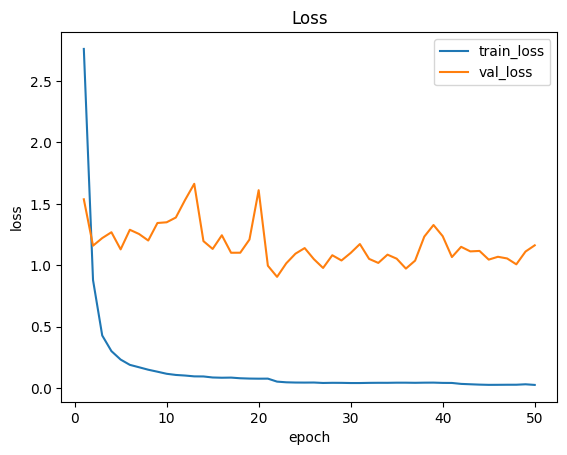

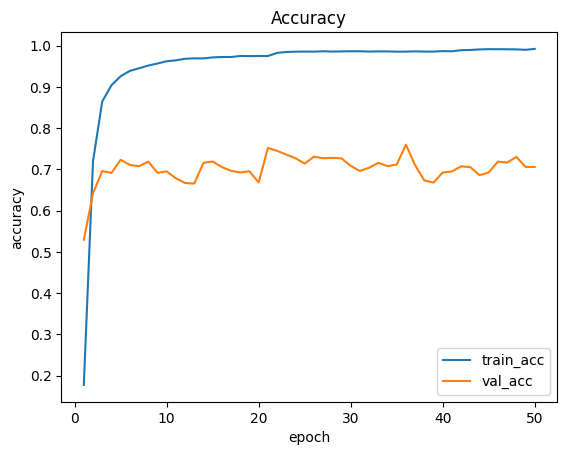

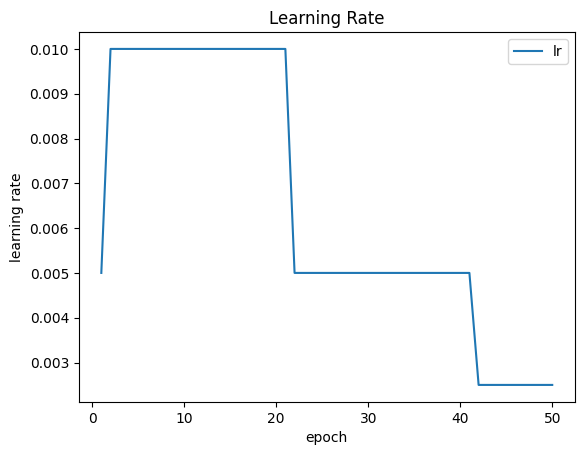

In [13]:
if not hist.empty:
    plt.figure()
    plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Loss")
    plt.show()

    plt.figure()
    plt.plot(hist["epoch"], hist["train_acc"], label="train_acc")
    plt.plot(hist["epoch"], hist["val_acc"], label="val_acc")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Accuracy")
    plt.show()

    plt.figure()
    plt.plot(hist["epoch"], hist["lr"], label="lr")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("learning rate")
    plt.title("Learning Rate")
    plt.show()

## 11) Best-model evaluation

val eval: 100%|██████████| 34/34 [00:10<00:00,  3.38it/s]


Accuracy: 0.7600369173973235
Macro F1: 0.7518491600734906

Classification report:

                          precision    recall  f1-score   support

           C1_Drive_Safe     0.4929    0.6161    0.5476       224
                C2_Sleep     0.7185    0.5534    0.6252       309
              C3_Yawning     0.8519    0.8798    0.8656       183
            C4_Talk_Left     0.9848    0.9923    0.9885       261
           C5_Talk_Right     1.0000    0.3088    0.4718       217
            C6_Text_Left     1.0000    0.8069    0.8931       145
           C7_Text_Right     0.9720    0.6123    0.7514       227
              C8_Make_Up     0.7486    0.9776    0.8479       268
            C9_Look_Left     0.9405    0.7190    0.8150       242
          C10_Look_Right     0.7330    0.9790    0.8383       143
             C11_Look_Up     0.9921    0.8562    0.9191       146
           C12_Look_Down     0.3527    0.7192    0.4733       203
          C13_Smoke_Left     0.9000    0.9512    0.9249   

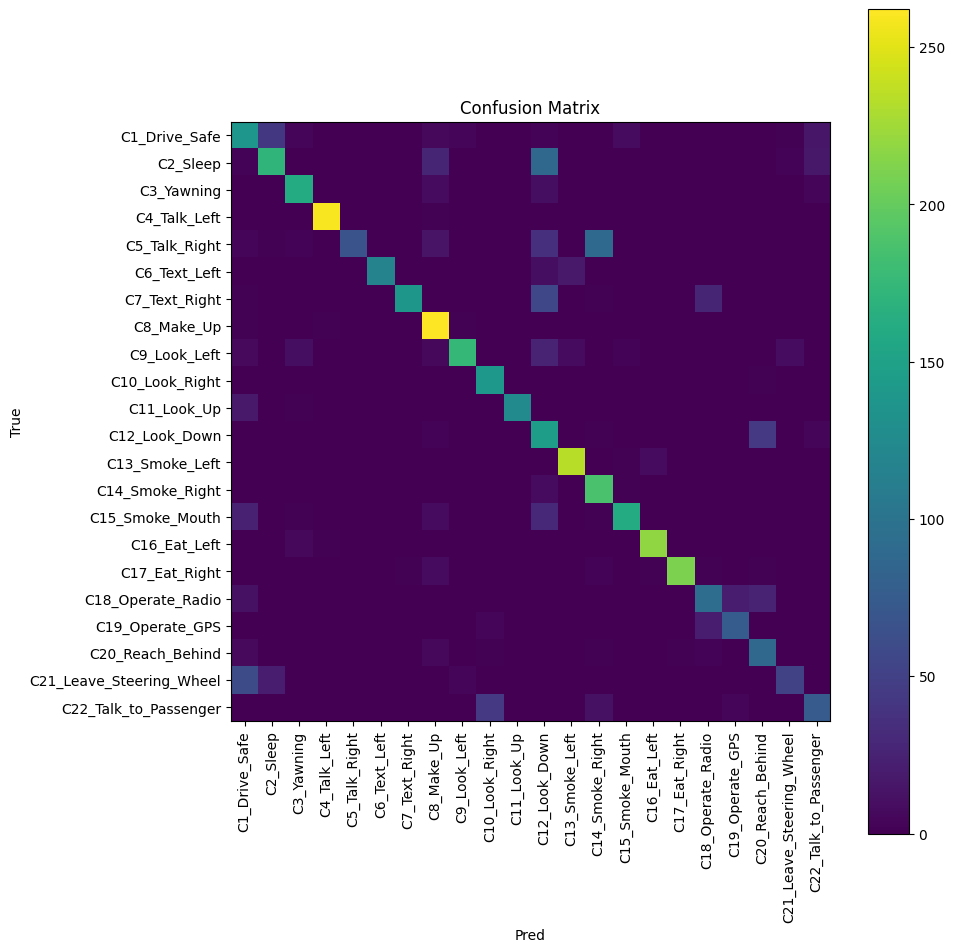

In [14]:
best_model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)
in_features = best_model.classifier[-1].in_features
best_model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)

state_dict = torch.load(best_path, map_location=device)
best_model.load_state_dict(state_dict)
best_model = best_model.to(device).eval()

y_true_all, y_pred_all = [], []
with torch.no_grad():
    for xb, yb in tqdm(val_loader, desc="val eval"):
        xb = xb.to(device, non_blocking=True)
        logits = best_model(xb)
        preds = logits.argmax(1).cpu().numpy()
        y_pred_all.append(preds)
        y_true_all.append(yb.numpy())

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print("Accuracy:", accuracy_score(y_true_all, y_pred_all))
print("Macro F1:", f1_score(y_true_all, y_pred_all, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(10, 10))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=90)
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.xlabel("Pred")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()

## 12) Quick inference preview

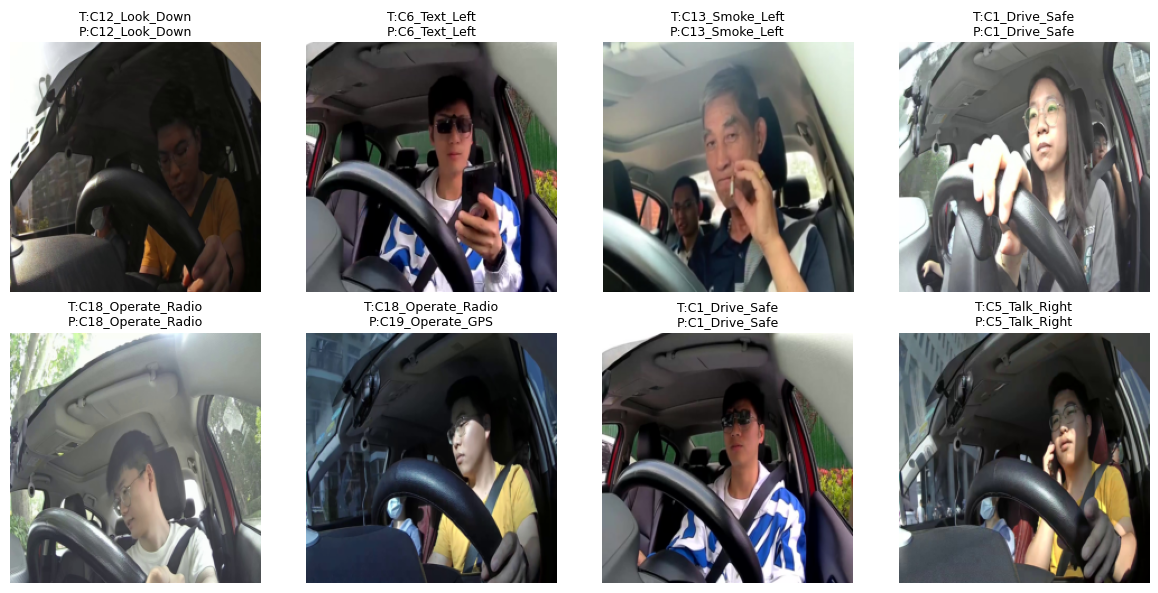

In [15]:
def denorm(x, mean, std):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return (x * std_t) + mean_t

best_model.eval()
sample_count = min(8, len(val_ds))
sample_idx = np.random.choice(len(val_ds), size=sample_count, replace=False)
samples = [val_ds[i] for i in sample_idx]
xb = torch.stack([s[0] for s in samples]).to(device)
yb = np.array([s[1] for s in samples])

with torch.no_grad():
    logits = best_model(xb)
    probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(1).cpu().numpy()

plt.figure(figsize=(12, 6))
for i in range(sample_count):
    ax = plt.subplot(2, math.ceil(sample_count / 2), i + 1)
    img = denorm(samples[i][0].cpu(), mean, std).clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0))
    ax.axis("off")
    ax.set_title(f"T:{CLASS_NAMES[yb[i]]}\nP:{CLASS_NAMES[pred[i]]}", fontsize=9)
plt.tight_layout()
plt.show()